# Micro Proyecto No. 1
## Generación de paleta de colores a partir de imágenes con técnicas de machine learning no supervisado
### Machine Learning no Supervisado

**Universidad de los Andes**

**Integrantes:**

* David Cortes Mantilla
* Natalia Serna Hernandez



## Elección de imágenes

 Para la elección de imagenes escogimos una mezcla de colores obscuros, como negros, marrones, rojos y un contraste con colores vivos como naranjas y verdes, adicional, se escogio una pequeña selección de colores pastel con el objetivo de generar una paleta de colores interesantes para aprender como funciona el procesamiento de la IA

- Importamos las librerías necesarias para desarrollar la actividad

In [ ]:

import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth



- Definimos la funcion de cargue de imágenes desde disco para su procesamiento, el cual debe devolver un arreglo de largo y ancho, reordenando los canales RGB con COLOR_BGR2RG y aplanando las dimensiones espaciales.

In [ ]:

def load_images(root_path, file_names, flatten=True, normalize=True):

    image_list = list()
    for file in file_names:
        img = cv2.imread(os.path.join(root_path, file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if flatten:
            img = img.reshape((-1, 3))
        if normalize:
            img = img / 255.0
        image_list.append(img)
    return image_list

- Listamos el contenido de la carpeta para obtener los nombres de los archivos que posteriormete pasarán por load_images asegurandonos de no tener
subdirectorios y archivos ocultos para evitar problemas.

In [ ]:
root_path = 'images'
img_files = os.listdir(root_path)
img_files

['akseli-gallen-kallela_symposium-1894.jpg',
 'hiroshige_hakone-kosuizu.jpg',
 'adolf-hitler_perchtoldsdorg-castle-and-church.jpg',
 'albrecht-altdorfer_christ-on-the-cross.jpg',
 'akseli-gallen-kallela_lemmink-inen-s-mother-1897.jpg',
 'albert-gleizes_the-schoolboy-1924.jpg',
 'antonio-ligabue_quadro.jpg',
 'abdullah-suriosubroto_indonesian-landscape-3.jpg']

- Se ejecuta el cargue en crudo de las imagenes sin modificaciones 

In [ ]:

img_original = load_images(root_path, img_files, flatten=False, normalize=False)
img_original

[array([[[ 82,  27,  59],
         [ 85,  30,  62],
         [ 90,  35,  67],
         ...,
         [ 56,  70,  71],
         [ 58,  72,  73],
         [ 58,  72,  73]],
 
        [[ 82,  27,  59],
         [ 85,  30,  62],
         [ 90,  35,  67],
         ...,
         [ 56,  70,  71],
         [ 57,  71,  72],
         [ 57,  71,  72]],
 
        [[ 86,  29,  62],
         [ 88,  31,  64],
         [ 92,  35,  68],
         ...,
         [ 54,  68,  69],
         [ 56,  70,  71],
         [ 55,  69,  70]],
 
        ...,
 
        [[218, 197, 166],
         [221, 200, 169],
         [221, 200, 169],
         ...,
         [197, 146, 127],
         [192, 141, 122],
         [191, 140, 121]],
 
        [[216, 195, 164],
         [220, 199, 168],
         [222, 201, 170],
         ...,
         [201, 150, 131],
         [197, 146, 127],
         [195, 144, 125]],
 
        [[217, 196, 165],
         [221, 200, 169],
         [223, 202, 171],
         ...,
         [204, 153, 134],
  

- Adicional, se cargan las imagenes como una lista de pixeles, con valores [0, 1]

In [ ]:

img_list = load_images(root_path, img_files, flatten=True, normalize=True)
img_list

[array([[0.32156863, 0.10588235, 0.23137255],
        [0.33333333, 0.11764706, 0.24313725],
        [0.35294118, 0.1372549 , 0.2627451 ],
        ...,
        [0.8       , 0.6       , 0.5254902 ],
        [0.78039216, 0.58039216, 0.50588235],
        [0.77647059, 0.57647059, 0.50196078]], shape=(2614233, 3)),
 array([[0.87058824, 0.79607843, 0.72941176],
        [0.85882353, 0.78431373, 0.71764706],
        [0.84313725, 0.76862745, 0.70196078],
        ...,
        [0.9372549 , 0.94117647, 0.87843137],
        [0.92156863, 0.9254902 , 0.8627451 ],
        [0.92156863, 0.9254902 , 0.8627451 ]], shape=(2866268, 3)),
 array([[0.65098039, 0.63529412, 0.52156863],
        [0.67058824, 0.65490196, 0.54117647],
        [0.71372549, 0.69803922, 0.58431373],
        ...,
        [0.72156863, 0.72941176, 0.71764706],
        [0.7254902 , 0.73333333, 0.72156863],
        [0.72941176, 0.7372549 , 0.7254902 ]], shape=(2121370, 3)),
 array([[0.48627451, 0.37254902, 0.21568627],
        [0.46666667, 

- Confirmamos las formas de ambas versiones de la imagen para confirmar que todo este según lo esperado y seleccionamos 8 clusters debido a que las imagenes son muy diferentes entre sí lo consideramos un equilibrio para la paleta de colores sin desear una reconstrucción fiel 

In [ ]:
img_original[0].shape
img_list[0].shape

num_clusters = 8

- Continuamos con la segmentación de imagenes entrenando sobre la imagen ya aplanada y normalizada con el método de KMeans con el objetivo de identificar el mejor método para recorrer todas las imagenes.

In [ ]:

kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(img_list[0])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](8, 3)",

- Paleta de colores resultante con centroides

In [ ]:

labels = kmeans.labels_
centroids = kmeans.cluster_centers_
centroids

array([[0.86823452, 0.72166205, 0.50680582],
       [0.06302891, 0.08555401, 0.09272233],
       [0.53411392, 0.22586404, 0.28173412],
       [0.35176282, 0.18175887, 0.23310886],
       [0.64523856, 0.37888333, 0.33336116],
       [0.15052005, 0.17573751, 0.21563187],
       [0.9051344 , 0.86125508, 0.69197033],
       [0.76969203, 0.53802432, 0.40697453]])

- Agregamos una mascara o imagen segmentada con normalización en 255

In [ ]:

img_segmented = centroids[labels]*255
img_segmented = img_segmented.reshape(img_original[0].shape)

- Imprimimos el resultado del proceso

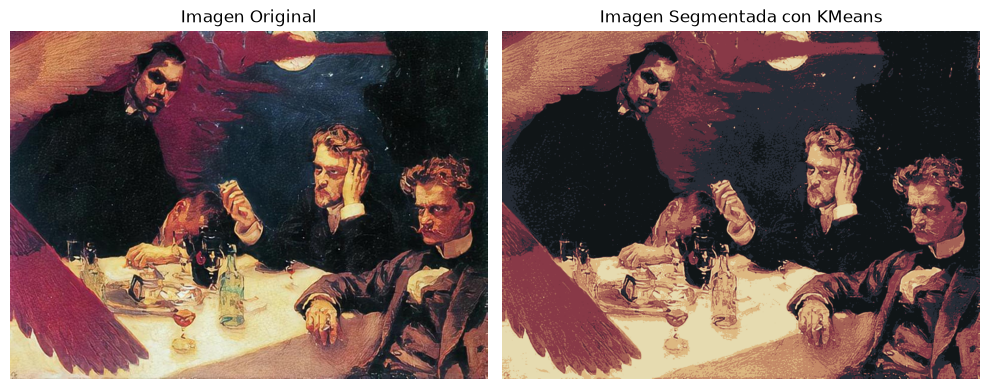

['akseli-gallen-kallela_symposium-1894.jpg', 'hiroshige_hakone-kosuizu.jpg', 'adolf-hitler_perchtoldsdorg-castle-and-church.jpg', 'albrecht-altdorfer_christ-on-the-cross.jpg', 'akseli-gallen-kallela_lemmink-inen-s-mother-1897.jpg', 'albert-gleizes_the-schoolboy-1924.jpg', 'antonio-ligabue_quadro.jpg', 'abdullah-suriosubroto_indonesian-landscape-3.jpg']
akseli-gallen-kallela_symposium-1894.jpg
(1381, 1893, 3)
(1381, 1893, 3)


In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.imshow(img_original[0])
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Imagen Segmentada con KMeans')
plt.imshow(img_segmented.astype(np.uint8))
plt.axis('off')

plt.tight_layout()
plt.show()

print(img_files)
print(img_files[0])
print(img_original[0].shape)
print(img_segmented.shape)

### MEANSHIFT
Decidimos usar ambos métodos con solo 1 imagen para identificar el mejor método de segmentación estimamos la ventana debido a que con este método no seleccionamos los clusters

In [ ]:

bandwidth = estimate_bandwidth(img_list[0], quantile=0.2, n_samples=100)


- Con la ventana definida realizamos la aplicación del algoritmo

In [ ]:
meanshift = MeanShift(bandwidth=bandwidth, bin_seeding=True)
meanshift.fit(img_list[0])

,"bandwidth bandwidth: float, default=NoneBandwidth used in the flat kernel.If not given, the bandwidth is estimated usingsklearn.cluster.estimate_bandwidth; see the documentation for thatfunction for hints on scalability (see also the Notes, below).",np.float64(0....6358475703227)
,"bin_seeding bin_seeding: bool, default=FalseIf true, initial kernel locations are not locations of allpoints, but rather the location of the discretized version ofpoints, where points are binned onto a grid whose coarsenesscorresponds to the bandwidth. Setting this option to True will speedup the algorithm because fewer seeds will be initialized.The default value is False.Ignored if seeds argument is not None.",True
,"seeds seeds: array-like of shape (n_samples, n_features), default=NoneSeeds used to initialize kernels. If not set,the seeds are calculated by clustering.get_bin_seedswith bandwidth as the grid size and default values forother parameters.",None
,"min_bin_freq min_bin_freq: int, default=1To speed up the algorithm, accept only those bins with at leastmin_bin_freq points as seeds.",1
,"cluster_all cluster_all: bool, default=TrueIf true, then all points are clustered, even those orphans that arenot within any kernel. Orphans are assigned to the nearest kernel.If false, then orphans are given cluster label -1.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. The following tasks benefitfrom the parallelization:- The search of nearest neighbors for bandwidth estimation and label assignments. See the details in the docstring of the ``NearestNeighbors`` class.- Hill-climbing optimization for all seeds.See :term:`Glossary <n_jobs>` for more details.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"max_iter max_iter: int, default=300Maximum number of iterations, per seed point before the clusteringoperation terminates (for that seed point), if has not converged yet... versionadded:: 0.22",300
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers.","ndarray[float64](3, 3)","[[0.08,0.11,0.12], [0.53,0.25,0.29], [0.9 ,0.82,0.63]]"
"labels_ labels_: ndarray of shape (n_samples,)Labels of each point.","ndarray[int64](2614233,)","[1,1,1,...,2,2,2]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3


- Vamos a ver la capa de colores resultante como una lista de centroides:

In [ ]:
labels = meanshift.labels_
centroids = meanshift.cluster_centers_
centroids

array([[0.08464112, 0.10606669, 0.12088517],
       [0.53158681, 0.24502628, 0.28597808],
       [0.89657527, 0.82097376, 0.6262042 ]])

- Generamos la máscara para poder observar el resultado del proceso

In [ ]:
img_segmented = centroids[labels]*255
img_segmented = img_segmented.reshape(img_original[0].shape)

- Imprimimos la imagen original y la segmentada

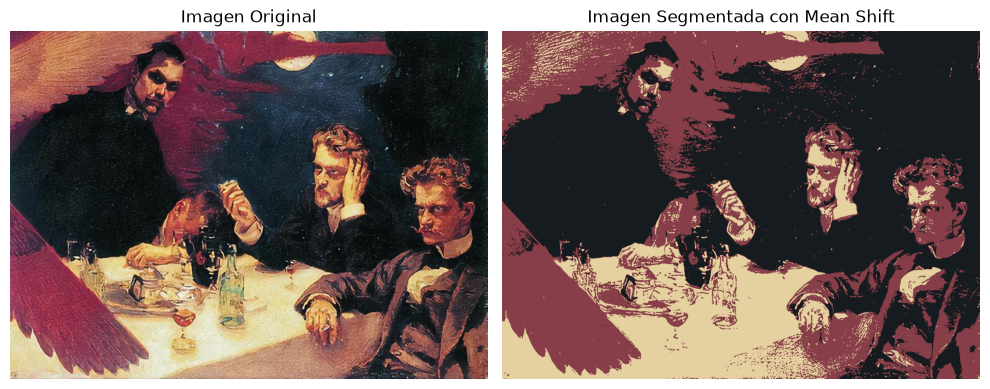

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.imshow(img_original[0])
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Imagen Segmentada con Mean Shift')
plt.imshow(img_segmented.astype(np.uint8))
plt.axis('off')

plt.tight_layout()
plt.show()

## Justificacion de elección de método.

Al elegir 8 clusters en KMeans observamos más detalle en la imagen con respecto a la agrupada por Mean Shift, sin embargo, se evidencia mejor segmentación con Mean Shift, al no tener que elegir la k manualmente agregando que es un método más pesado en cuestión de tiempo de procesamiento.

Al ser el objetivo del microproyecto una paleta de colores representativa donde deseamos colores dominantes y no fidelidad de imagen, elegimos la segmentación con Mean Shift para todas las imágenes considerando que son solo 8 imágenes por lo tanto el tiempo es razonable y cumple el objetivo de selección automática de K.

- Con la elección del método, realizamos un ciclo que recorra las imagenes, imprimiendo las k y sus nombres y Creamos números aleatorios de NumPy

In [ ]:

rng = np.random.default_rng(42)
resultados = []

#Ciclo para las imagenes línea a línea devolviendo posici+on y nombre 
for i, nombre in enumerate(img_files):
    #Toma la imagen aplanada y normalizada por vuelta
    X = img_list[i]
    #Escoge posiciones al azar entre 0 y el total de pixeles evitando repeticiones
    idx = rng.choice(len(X), size=min(5000, len(X)), replace=False)
    muestra = X[idx]

    #Calcula el radio de busqueda de Meanshift bw - determina indirectamente cuantos clusters salen
    bw = estimate_bandwidth(muestra, quantile=0.1, n_samples=1000)
    #entrenamiento con una ventana de radio bw
    ms = MeanShift(bandwidth=bw, bin_seeding=True)
    ms.fit(muestra)

    resultados.append({
        'archivo': nombre,
        'indice': i,
        'bandwidth': bw,
        'k': len(ms.cluster_centers_),
        'modelo': ms,
        'centroides': ms.cluster_centers_
    })

    print(f"{nombre}: k={len(ms.cluster_centers_)}")

akseli-gallen-kallela_symposium-1894.jpg: k=8
hiroshige_hakone-kosuizu.jpg: k=8
adolf-hitler_perchtoldsdorg-castle-and-church.jpg: k=7
albrecht-altdorfer_christ-on-the-cross.jpg: k=4
akseli-gallen-kallela_lemmink-inen-s-mother-1897.jpg: k=8
albert-gleizes_the-schoolboy-1924.jpg: k=7
antonio-ligabue_quadro.jpg: k=4
abdullah-suriosubroto_indonesian-landscape-3.jpg: k=7


- Teniendo en cuenta que no podíamos confirmar que el cuartil escogido inicialmente fuera el mejor investigamos como realizar una búsqueda del mejor cuartile, encontrando la forma de con un ciclo recorrer q en las funciones de estimate_bandwidth 

In [ ]:

for i, nombre in enumerate(img_files):
    X = img_list[i]
    idx = rng.choice(len(X), size=min(5000, len(X)), replace=False)
    muestra = X[idx]

    print(f"\n{nombre}")
    for q in [0.05, 0.1, 0.15, 0.2]:
        bw = estimate_bandwidth(muestra, quantile=q, n_samples=1000)
        ms = MeanShift(bandwidth=bw, bin_seeding=True).fit(muestra)
        print(f"  quantile={q}: bandwidth={bw:.4f}, k={len(ms.cluster_centers_)}")



akseli-gallen-kallela_symposium-1894.jpg
  quantile=0.05: bandwidth=0.0804, k=13
  quantile=0.1: bandwidth=0.1211, k=6
  quantile=0.15: bandwidth=0.1587, k=4
  quantile=0.2: bandwidth=0.1955, k=3

hiroshige_hakone-kosuizu.jpg
  quantile=0.05: bandwidth=0.0949, k=15
  quantile=0.1: bandwidth=0.1401, k=8
  quantile=0.15: bandwidth=0.1836, k=4
  quantile=0.2: bandwidth=0.2200, k=3

adolf-hitler_perchtoldsdorg-castle-and-church.jpg
  quantile=0.05: bandwidth=0.0551, k=13
  quantile=0.1: bandwidth=0.0771, k=5
  quantile=0.15: bandwidth=0.0978, k=3
  quantile=0.2: bandwidth=0.1184, k=3

albrecht-altdorfer_christ-on-the-cross.jpg
  quantile=0.05: bandwidth=0.0774, k=9
  quantile=0.1: bandwidth=0.1083, k=5
  quantile=0.15: bandwidth=0.1351, k=4
  quantile=0.2: bandwidth=0.1628, k=4

akseli-gallen-kallela_lemmink-inen-s-mother-1897.jpg
  quantile=0.05: bandwidth=0.0513, k=24
  quantile=0.1: bandwidth=0.0905, k=4
  quantile=0.15: bandwidth=0.1182, k=4
  quantile=0.2: bandwidth=0.1447, k=3

albe



- Con el cuartil 0.2 los grupos quedaban entre 2 y 4, son pocos para representar una obra con 0.05 se aumentan hasta 24 lo cual es demasiado para la segmentación de colores que buscamos, el 0.1 da entre 3 y 8, que es el rango donde la paleta sigue siendo viable 
- Definimos la función con sus parámetros

In [ ]:
def mostrar_paleta(centroides, titulo='Paleta', ancho_barra=100, alto=200):
    #Cuenta cuantos colores tiene la paleta
    k = len(centroides)
    #Crea el lienzo vacío donde vamos a pintar las franjas.
    paleta = np.zeros((alto, ancho_barra * k, 3))
    #Aquí creamos el ciclo encargado de pintar las franjas
    for j, color in enumerate(centroides):
        paleta[:, j*ancho_barra:(j+1)*ancho_barra] = color

    #funciones para definir las distancias entre colores, encabezados, eliminación de ejes numericos y renderización    

    plt.figure(figsize=(k * 1.2, 2))
    plt.imshow(paleta)
    plt.title(f"{titulo} (k={k})")
    plt.axis('off')
    plt.show()

- Imprimimos todas las paletas

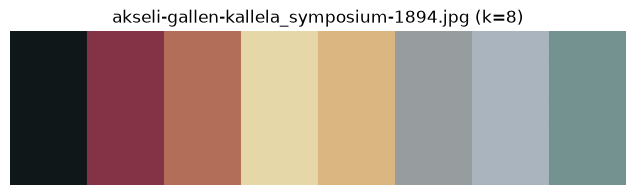

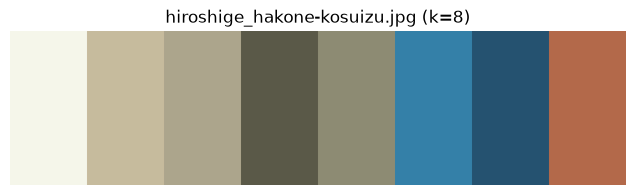

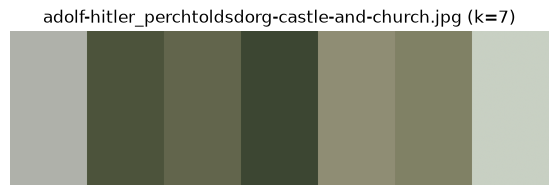

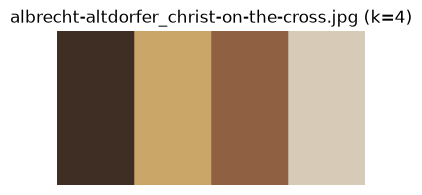

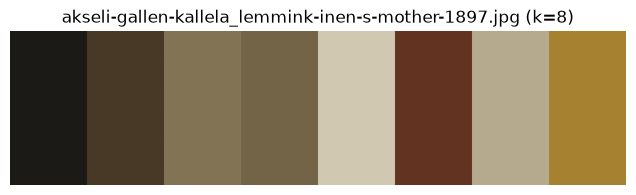

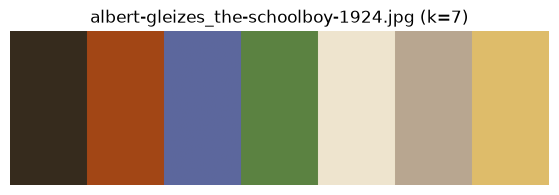

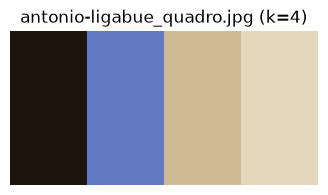

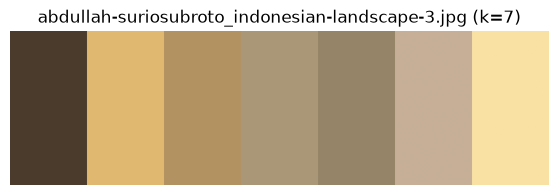

In [ ]:
for r in resultados:
    mostrar_paleta(r['centroides'], r['archivo'])

PCA
No aplica la eliminación de datos nulos como preparación de datos debido a que no existen al estar la imagen codificada en OpenCV el cual solo
entrega valores entre 0 y 255, por lo tanto un pixel no puede quedar vacío, adicional no aplica la eliminación de duplicados debido a que en este caso la frecuencia con la que aparece un pixel también nos dá información.
La única preparación realizada es la conversión de BGR a RGB aplanando los píxeles a n_pixeles 3.


Usamos la técnica de PCA para conservar la mayor cantidad de la dispersión original de los datos, es decir, buscar el mejor plano posible para la representación de los 3 ejes en un plano intentando perder la menor cantidad de información posible

In [67]:
#Se define r como disccionario de resultados, la lista de imagenes aplanadas creadas previamente. n_puntos y rng son variables por defecto
#para pixeles por grafico y generador de números aleatorios
def graficar_distribucion(r, img_list, n_puntos=3000, rng=None):
    #si rng viene vacío toma una nueva semilla con 42
    if rng is None:  
     rng = np.random.default_rng(42)

     #devuelve la matriz de (n_píxeles, 3) normalizada
    X = img_list[r['indice']]

    #sin reemplazar se escogen posiciones al azar por sus indices y extrae las filas correspondientes usando ese arreglo de posiciones
    idx = rng.choice(len(X), size=min(n_puntos, len(X)), replace=False)
    muestra = X[idx]

    #Toma el modelo ya entrenado y calcula los centroides más cercano en el espacio de RGB
    etiquetas = r['modelo'].predict(muestra)

    #crea el objeto exactamente con los 2 componentes
    pca = PCA(n_components=2)
    #Fit analiza los 3000 pixeles y encuentra las 2 direcciones, adicional los proyecta
    proyectado = pca.fit_transform(muestra)
    #proyecta los centroides usando el mismo plano ya calculado
    centros_proy = pca.transform(r['centroides'])

    #Crea la figura de tamaño fijo
    plt.figure(figsize=(7, 6))
    #Dibuja los pixeles
    plt.scatter(proyectado[:, 0], proyectado[:, 1],
                #Devuelve la matriz para cada punto
                                c=r['centroides'][etiquetas], s=8, alpha=0.6)
    #Marca los centroides con una X negra de tamaño 200 y borde blanco. Esa combinación de negro con contorno blanco, garantizando que se vean
    plt.scatter(centros_proy[:, 0], centros_proy[:, 1],
                c='black', marker='X', s=200, edgecolors='white')

    #etiquetas y cierre del gráfico
    var = pca.explained_variance_ratio_
    plt.xlabel(f"CP1 ({var[0]*100:.1f}% de varianza)")
    plt.ylabel(f"CP2 ({var[1]*100:.1f}% de varianza)")
    plt.title(f"{r['archivo']} (k={r['k']})")
    plt.show()


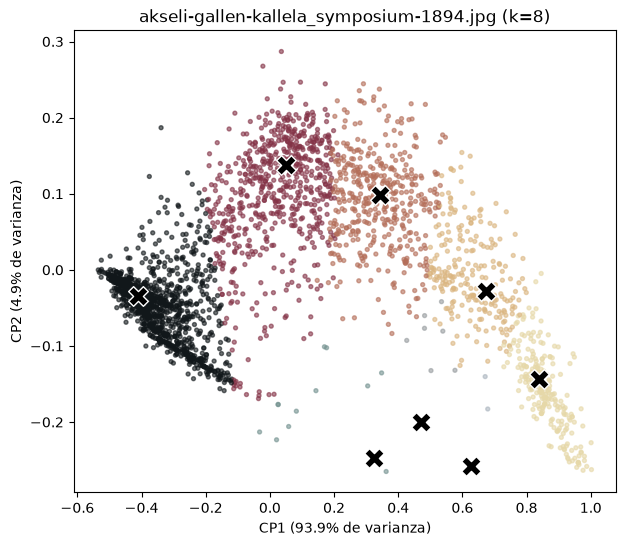

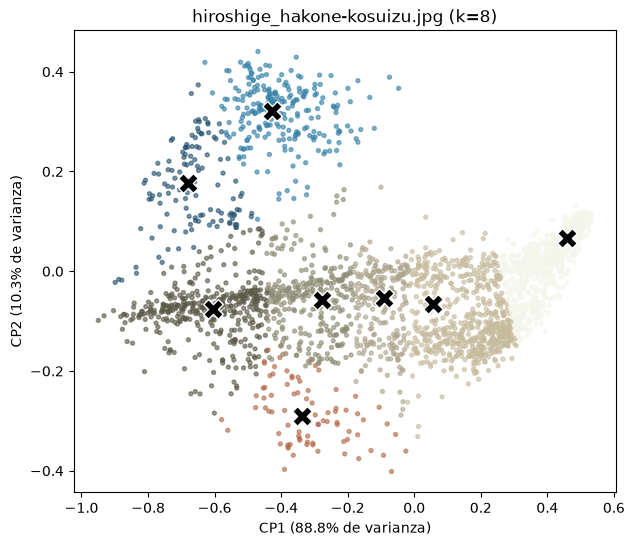

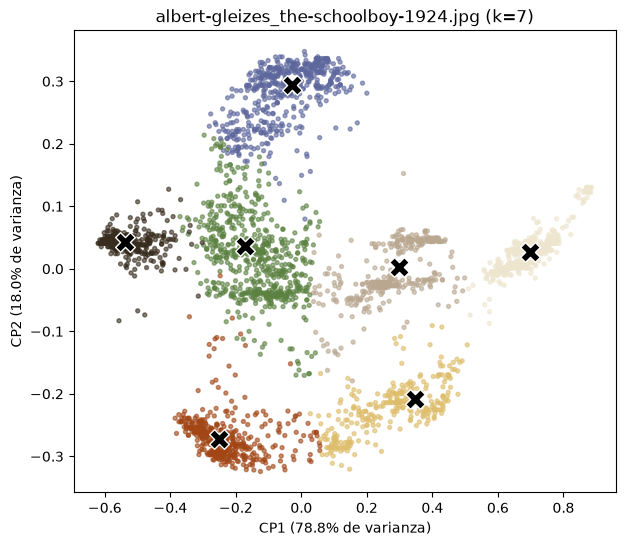

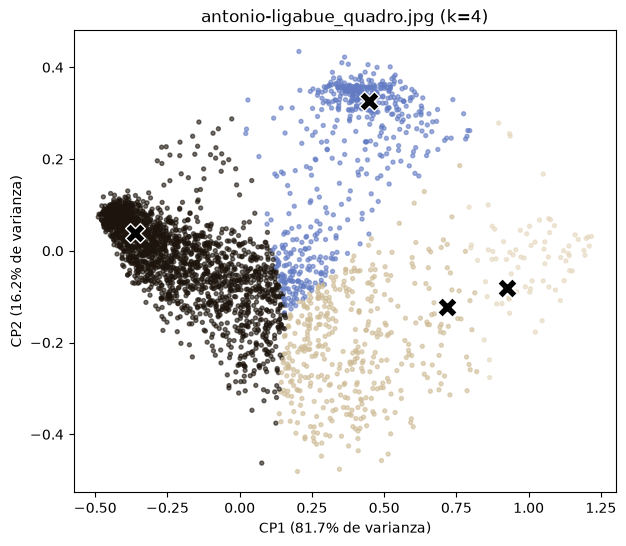

: 

In [ ]:
#Graficamos los resultados de solo 4
for i in [0, 1, 5, 6]:
    graficar_distribucion(resultados[i], img_list)
